## 1. Descriptive Statistics Analysis - Wine Quality Dataset

1. Tổng quan về cấu trúc bộ dữ liệu (Multivariate).
2. Tính toán các đại lượng thống kê: Mean, Variance cho Quần thể và Mẫu.
3. Phân tích hệ số tương quan giữa các biến.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))
from source.utils import mean, variance, standard_deviation, covariance, correlation

sns.set_style("whitegrid")

try:
    df = pd.read_csv("../data/WineQT.csv")
    features = df.drop(columns=["quality", "Id"])
    print("Tải dữ liệu thành công.")
except FileNotFoundError:
    print("không tìm thấy file dữ liệu. Vui lòng kiểm tra lại đường dẫn.")

print(df.head())

Tải dữ liệu thành công.
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8

## Tổng quan dữ liệu

In [15]:
print("Cấu trúc dữ liệu nhiều chiều")
print(f"Số lượng sample: {df.shape[0]}")
print(f"Số lượng cột (biến): {features.shape[1]}")
print("-" * 30)
df.info()

Cấu trúc dữ liệu nhiều chiều
Số lượng sample: 1143
Số lượng cột (biến): 11
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
mem

## Mean và Variance

In [16]:
# Lấy mẫu ngẫu nhiên 
N = len(df)
n_sample = 100
df_sample = df.sample(n=n_sample, random_state=42)

# Mean, Variance, and Standard Deviation of the Population
pop_mean = {col: mean(df[col]) for col in features.columns}
pop_var = {col: variance(df[col], is_population=True) for col in features.columns}
pop_std = {col: standard_deviation(df[col], is_population=True) for col in features.columns}

# 3. Mean and Variance of the Sample
sample_mean = {col: mean(df_sample[col]) for col in features.columns}
sample_var = {col: variance(df_sample[col], is_population=False) for col in features.columns}
sample_std = {col: standard_deviation(df_sample[col], is_population=False) for col in features.columns}

# Tạo bảng so sánh cho một biến cụ thể
rows = []
for col in features.columns:
    rows.append({
        "Variable": col,
        "Population Mean": pop_mean[col],
        "Sample Mean": sample_mean[col],
        "Population Variance": pop_var[col],
        "Sample Variance": sample_var[col],
        "Population Std": pop_std[col],
        "Sample Std": sample_std[col]
    })

comparison = pd.DataFrame(rows).set_index("Variable")
print("So sánh giữa Population và Sample:")
print(comparison)

So sánh giữa Population và Sample:
                      Population Mean  Sample Mean  Population Variance  \
Variable                                                                  
fixed acidity                8.311111     8.393000             3.051416   
volatile acidity             0.531339     0.536400             0.032240   
citric acid                  0.268364     0.269900             0.038651   
residual sugar               2.532152     2.477500             1.836904   
chlorides                    0.086933     0.088390             0.002232   
free sulfur dioxide         15.615486    14.190000           104.980539   
total sulfur dioxide        45.914698    40.460000          1073.727850   
density                      0.996730     0.996690             0.000004   
pH                           3.311015     3.302600             0.024522   
sulphates                    0.657708     0.660300             0.029010   
alcohol                     10.442111    10.507333             1.

## Phân tích tương quan

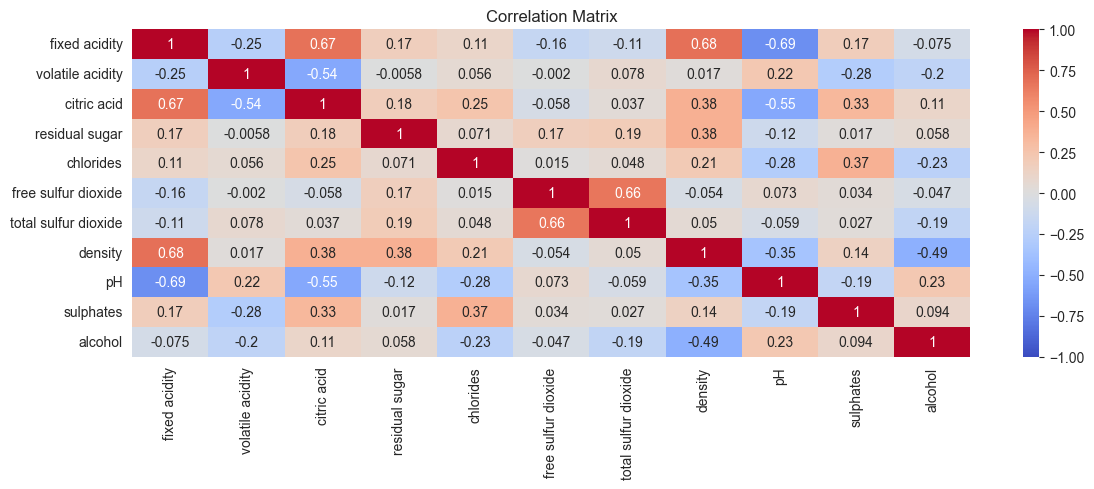

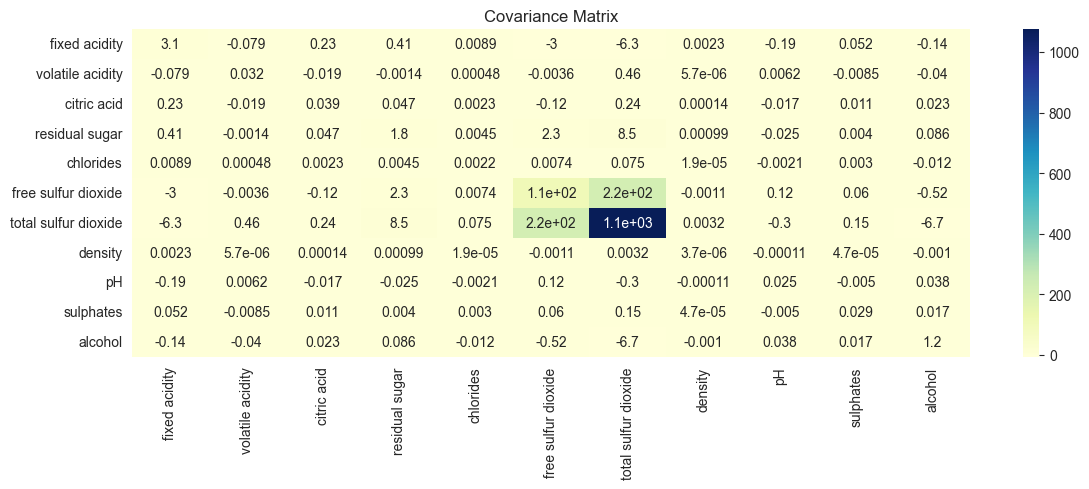

In [19]:
# Correlation Matrix & Correlation
var_list = features.columns.tolist()
p = len(var_list)

corr_matrix = np.zeros((p, p))
cov_matrix = np.zeros((p, p))

for i, vi in enumerate(var_list):
    for j, vj in enumerate(var_list):
        cov_matrix[i, j] = covariance(features[vi], features[vj], is_population=False)
        corr_matrix[i, j] = correlation(features[vi], features[vj])

cov_df = pd.DataFrame(cov_matrix, index=var_list, columns=var_list)
corr_df = pd.DataFrame(corr_matrix, index=var_list, columns=var_list)

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(corr_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
sns.heatmap(cov_df, annot=True, cmap="YlGnBu")
plt.title("Covariance Matrix")
plt.tight_layout()
plt.show()

## Visualization


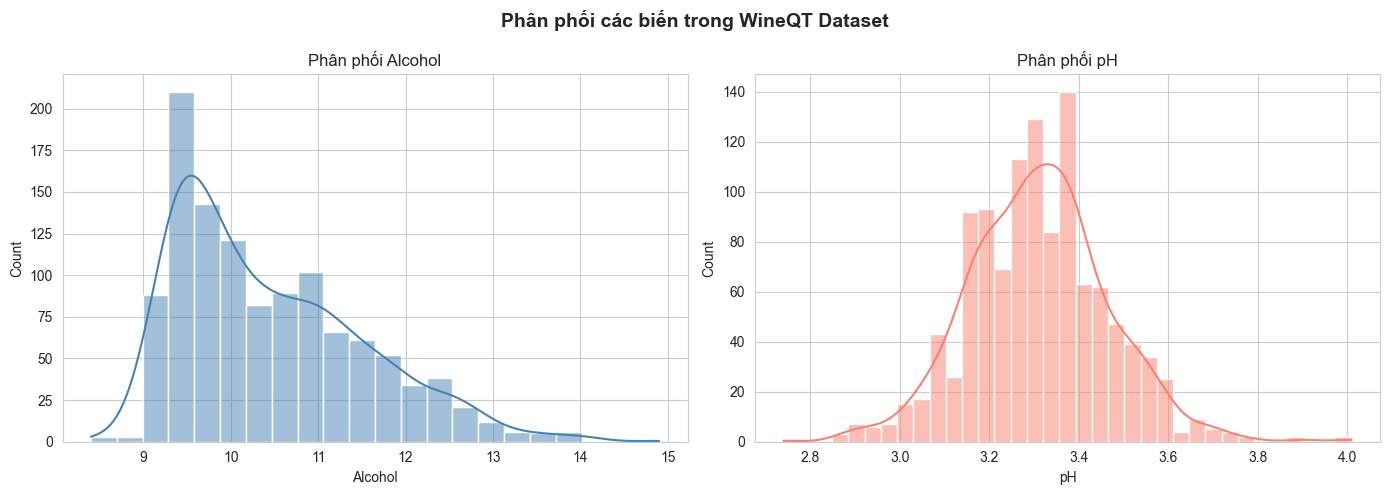

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(features["alcohol"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối Alcohol")
axes[0].set_xlabel("Alcohol")

sns.histplot(features["pH"], kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối pH")
axes[1].set_xlabel("pH")

plt.suptitle("Phân phối các biến trong WineQT Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../data/fig01_distributions.png", bbox_inches="tight")
plt.show()

In [24]:
# Minh hoạ ý nghĩa hình học với 2 biến: alcohol & volatile acidity
v1_name, v2_name = "alcohol", "volatile acidity"
v1 = features[v1_name].values
v2 = features[v2_name].values
x1_bar, x2_bar = pop_mean[v1_name], pop_mean[v2_name]

d1 = v1 - x1_bar   # deviation vector biến 1
d2 = v2 - x2_bar   # deviation vector biến 2
L1 = np.sqrt(np.dot(d1, d1))
L2 = np.sqrt(np.dot(d2, d2))
cos_theta = np.dot(d1, d2) / (L1 * L2)
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))

print(f"Biến 1: {v1_name}")
print(f"Mean = {x1_bar:.4f}")
print(f"Var = {pop_var[v1_name]:.4f}")
print(f"Std = {pop_std[v1_name]:.4f}")
print(f"||d1|| (Population Std x √n) = {L1:.4f}")
print()
print(f"Biến 2: {v2_name}")
print(f"Mean = {x2_bar:.4f}")
print(f"Var = {pop_var[v2_name]:.4f}")
print(f"Std = {pop_std[v2_name]:.4f}")
print(f"||d2|| = {L2:.4f}")
print()
print(f"Góc θ giữa d1 và d2 = {theta_deg:.2f}°")
print(f"cos(θ) = r(alcohol, volatile acidity) = {cos_theta:.4f}")
print()
print(f"Xác nhận: correlation() = {correlation(features[v1_name], features[v2_name]):.4f}")

Biến 1: alcohol
Mean = 10.4421
Var = 1.1701
Std = 1.0817
||d1|| (Population Std x √n) = 36.5712

Biến 2: volatile acidity
Mean = 0.5313
Var = 0.0322
Std = 0.1796
||d2|| = 6.0704

Góc θ giữa d1 và d2 = 101.77°
cos(θ) = r(alcohol, volatile acidity) = -0.2039

Xác nhận: correlation() = -0.2039


C:\Users\DUC AN\AppData\Local\Temp\ipykernel_4020\366352882.py:13: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DUC AN\AppData\Local\Temp\ipykernel_4020\366352882.py:13: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\DUC AN\AppData\Local\Temp\ipykernel_4020\366352882.py:14: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig("../data/fig01_scatter_geom.png", bbox_inches="tight")
C:\Users\DUC AN\AppData\Local\Temp\ipykernel_4020\366352882.py:14: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("../data/fig01_scatter_geom.png", bbox_inches="tight")


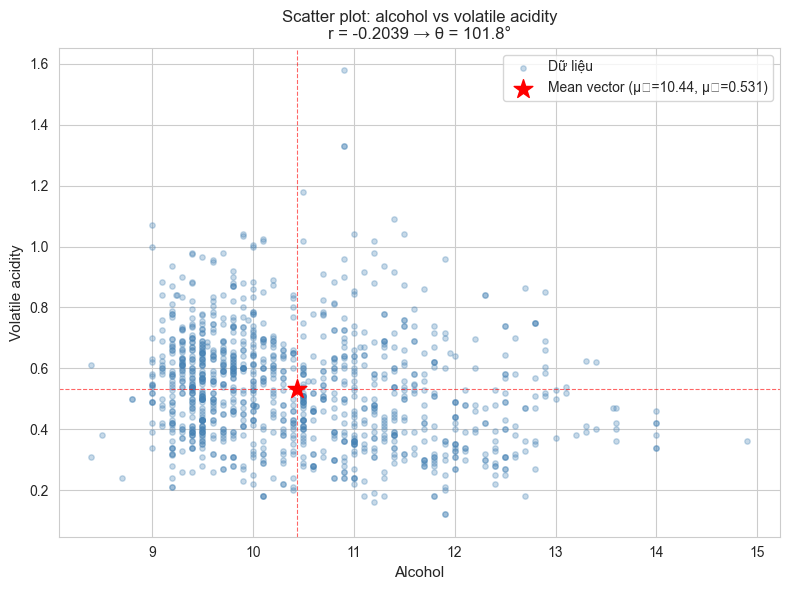

In [26]:
# Biểu đồ scatter + mean point để minh hoạ Mean Vector
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(features[v1_name], features[v2_name], alpha=0.3, s=15, color="steelblue", label="Dữ liệu")
ax.scatter([x1_bar], [x2_bar], s=200, color="red", zorder=5, marker="*",
           label=f"Mean vector (μ₁={x1_bar:.2f}, μ₂={x2_bar:.3f})")
ax.axvline(x1_bar, color="red", lw=0.8, ls="--", alpha=0.6)
ax.axhline(x2_bar, color="red", lw=0.8, ls="--", alpha=0.6)
ax.set_xlabel(v1_name.capitalize(), fontsize=11)
ax.set_ylabel(v2_name.capitalize(), fontsize=11)
ax.set_title(f"Scatter plot: {v1_name} vs {v2_name}\n"
             f"r = {cos_theta:.4f} → θ = {theta_deg:.1f}°", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../data/fig01_scatter_geom.png", bbox_inches="tight")
plt.show()